In [46]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib as plt

In [47]:
fashion_data = fashion_mnist.load_data()

In [48]:
(train_images, train_labels), (test_images, test_labels) = fashion_data

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

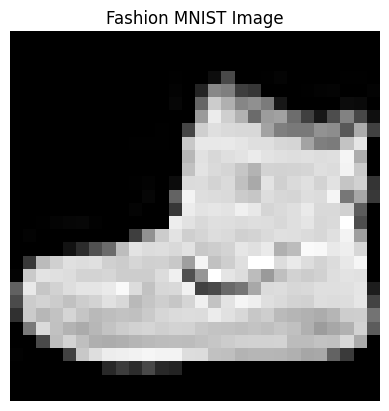

In [49]:
import matplotlib.pyplot as plt

plt.imshow(train_images[0], cmap="gray")
plt.title("Fashion MNIST Image")
plt.axis("off")

In [50]:
fashion_mnist.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [51]:
train_images, train_labels = fashion_mnist.load_data()[0]
test_images, test_labels = fashion_mnist.load_data()[1]

In [52]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Text(0.5, 1.0, '9')

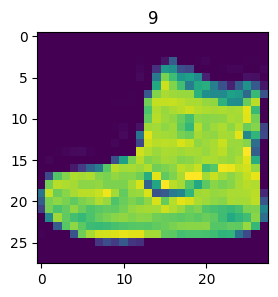

In [53]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.imshow(train_images[0])
plt.title(train_labels[0])

Text(0.5, 1.0, 'Sandal')

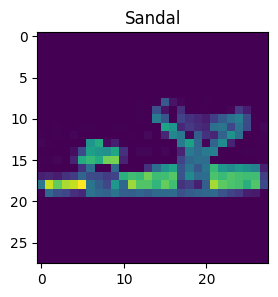

In [54]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.imshow(train_images[-1])
plt.title(class_names[train_labels[-1]])

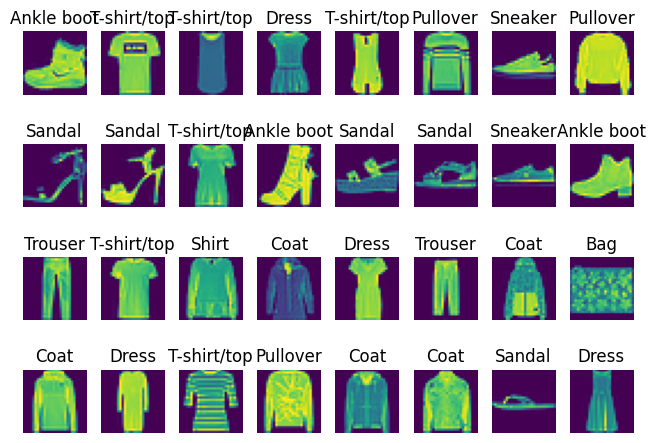

In [55]:
n_rows = 4
n_cols = 8
for row in range(n_rows):
     for col in range(n_cols):
         index = row * n_cols + col
         plt.subplot(n_rows, n_cols, index + 1)
         plt.imshow(train_images[index])
         plt.title(class_names[train_labels[index]])
         plt.axis("off")
plt.tight_layout()
plt.show()

In [56]:
train_images_scaled = train_images.reshape(60000, 28 , 28, 1) / 255.0
test_images_scaled = test_images.reshape(10000, 28 , 28, 1) / 255.0

In [57]:
# CNN architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
cnn_model = Sequential()
cnn_model.add(Conv2D(128, (3,3), activation='relu', input_shape=(28,28,1)))
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D((2,2)))
#cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(Flatten())
cnn_model.add(Dense(100, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(10, activation='softmax'))


In [58]:
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       160,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,182 (922.59 KB)

 Trainable params: 236,182 (922.59 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [60]:
history = cnn_model.fit(train_images_scaled, train_labels, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.7718 - loss: 0.6372 - val_accuracy: 0.8627 - val_loss: 0.3742
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.8525 - loss: 0.4140 - val_accuracy: 0.8795 - val_loss: 0.3342
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.8711 - loss: 0.3591 - val_accuracy: 0.8889 - val_loss: 0.3004
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.8826 - loss: 0.3248 - val_accuracy: 0.8981 - val_loss: 0.2783
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.8898 - loss: 0.3054 - val_accuracy: 0.9018 - val_loss: 0.2718
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.8986 - loss: 0.2821 - val_accuracy: 0.9046 - val_loss: 0.2586
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9043 - loss: 0.2643 - val_accuracy: 0.9042 - val_loss: 0.2591
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9079 - loss: 0.2506 - 

In [61]:
from tensorflow.keras.callbacks import EarlyStopping
early_stp = EarlyStopping(monitor='val_accuracy', patience=2, )

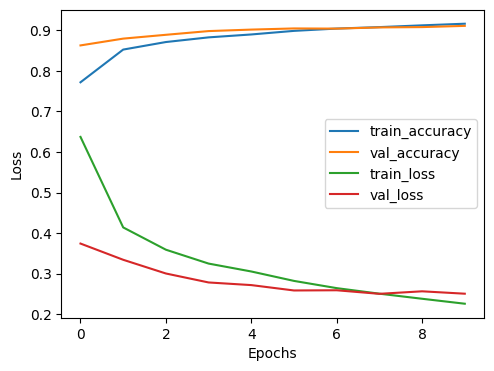

In [62]:
# accuracy and loss curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [63]:
loss, accuracy = cnn_model.evaluate(test_images_scaled, test_labels, verbose=1)
print("Test loss:", loss)
print("Test accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9050 - loss: 0.2699
Test loss: 0.2699153423309326
Test accuracy: 0.9049999713897705


In [66]:
x_new = test_images_scaled[0:5]
predictions = cnn_model.predict(x_new)
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


array([[1.0126487e-11, 7.3202803e-14, 1.5995602e-14, 3.7031503e-13,
        9.1936710e-15, 5.4879860e-07, 2.1564783e-11, 9.1371758e-06,
        1.5932930e-11, 9.9999022e-01],
       [9.0084933e-07, 2.1894560e-13, 9.9993968e-01, 3.4561662e-09,
        1.9888230e-05, 5.1716372e-15, 3.9597835e-05, 5.0865979e-18,
        5.6589841e-12, 9.2619463e-16],
       [1.0710846e-12, 1.0000000e+00, 2.4515392e-17, 9.5539191e-13,
        2.5018103e-16, 5.5662365e-18, 2.8918650e-14, 1.3720087e-24,
        7.6458513e-14, 5.0739862e-22],
       [4.9220343e-14, 1.0000000e+00, 8.8446097e-18, 7.7426062e-14,
        1.5031600e-16, 7.3913506e-20, 3.5306377e-15, 3.2622361e-27,
        1.7402878e-15, 1.5650082e-23],
       [1.0791631e-01, 1.2237497e-06, 1.4910548e-02, 8.8778668e-04,
        7.5665982e-03, 2.2309652e-07, 8.6871660e-01, 9.1686943e-11,
        7.2011221e-07, 1.7852044e-09]], dtype=float32)

In [68]:
[class_names[i] for i in predictions.argmax(axis=1)]

['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt']

In [70]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahmoudreda55/satellite-image-classification")

print("Path to dataset files:", path)

/home/haze/Code/Green_AI_shit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 21.8M/21.8M [00:28<00:00, 810kB/s] 

Extracting files...


Path to dataset files: /home/haze/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1


In [72]:
import os
import pandas as pd

# Build labels from dataset folders (uses `path` from your Kaggle download cell)
if "labels" not in globals():
    labels = {}
    for root, _, files in os.walk(path):
        if any(f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")) for f in files):
            labels[root] = os.path.basename(root)

# Create/reset dataframe
data = pd.DataFrame(columns=["image_path", "label"])

# Validate folder paths
for folder in labels:
    if not os.path.exists(folder):
        print(f"Warning: The folder {folder} does not exist.")
        continue

    # Process each image in the folder
    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)
        if os.path.isfile(image_path):  # Only process files
            label = labels[folder]
            data = pd.concat([data, pd.DataFrame({'image_path': [image_path], 'label': [label]})], ignore_index=True)

# Display the resulting DataFrame
print(data)

                                             image_path   label
0     /home/haze/.cache/kagglehub/datasets/mahmoudre...  cloudy
1     /home/haze/.cache/kagglehub/datasets/mahmoudre...  cloudy
2     /home/haze/.cache/kagglehub/datasets/mahmoudre...  cloudy
3     /home/haze/.cache/kagglehub/datasets/mahmoudre...  cloudy
4     /home/haze/.cache/kagglehub/datasets/mahmoudre...  cloudy
...                                                 ...     ...
5626  /home/haze/.cache/kagglehub/datasets/mahmoudre...   water
5627  /home/haze/.cache/kagglehub/datasets/mahmoudre...   water
5628  /home/haze/.cache/kagglehub/datasets/mahmoudre...   water
5629  /home/haze/.cache/kagglehub/datasets/mahmoudre...   water
5630  /home/haze/.cache/kagglehub/datasets/mahmoudre...   water

[5631 rows x 2 columns]


In [73]:
data.to_csv("satellite_images_labels.csv", index=False)

In [74]:
image_df = pd.read_csv("satellite_images_labels.csv")
image_df.head()

,image_path,label
0,/home/haze/.cache/kagglehub/datasets/mahmoudre...,cloudy
1,/home/haze/.cache/kagglehub/datasets/mahmoudre...,cloudy
2,/home/haze/.cache/kagglehub/datasets/mahmoudre...,cloudy
3,/home/haze/.cache/kagglehub/datasets/mahmoudre...,cloudy
4,/home/haze/.cache/kagglehub/datasets/mahmoudre...,cloudy


In [75]:
from sklearn.model_selection import train_test_split
x_train, x_test = train_test_split(data, test_size=0.2)


In [77]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
	rescale=1./255,
	shear_range=0.2,
	zoom_range=0.2,
	horizontal_flip=True,
	rotation_range=45,
	vertical_flip=True,
	fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [78]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=x_train,
    directory=None,
    x_col="image_path",
    y_col="label",
    target_size=(255, 255),
    batch_size=32,
    class_mode="categorical"
)

Found 4504 validated image filenames belonging to 4 classes.


In [79]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=x_test,
    directory=None,
    x_col="image_path",
    y_col="label",
    target_size=(255, 255),
    batch_size=32,
    class_mode="categorical"
)

Found 1127 validated image filenames belonging to 4 classes.


In [86]:
# CNN architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
sat_cnn_model = Sequential()
sat_cnn_model.add(Conv2D(100, (3,3), activation='relu', input_shape=(255,255,3)))
sat_cnn_model.add(MaxPooling2D((2,2)))
sat_cnn_model.add(Conv2D(50, (3,3), activation='relu'))
sat_cnn_model.add(MaxPooling2D((2,2)))
#sat_cnn_model.add(Conv2D(128, (3,3), activation='relu'))
sat_cnn_model.add(Flatten())
sat_cnn_model.add(Dense(50, activation='relu'))
sat_cnn_model.add(Dropout(0.5))
sat_cnn_model.add(Dense(4, activation='softmax'))

In [87]:
sat_cnn_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 253, 253, 100)  │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 126, 126, 100)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 124, 124, 50)   │        45,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 62, 62, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 192200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 50)             │     9,610,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,658,104 (36.84 MB)

 Trainable params: 9,658,104 (36.84 MB)

 Non-trainable params: 0 (0.00 B)

In [90]:
# compile 
sat_cnn_model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [91]:
from tensorflow.keras.callbacks import EarlyStopping
early_stp = EarlyStopping(monitor='val_accuracy', patience=10 ,)

In [93]:
history = sat_cnn_model.fit(train_generator, epochs=1, validation_data=test_generator, callbacks=[early_stp])

141/141 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.5608 - loss: 0.7729 - val_accuracy: 0.8580 - val_loss: 0.5264
